# 기초통계 통합 프로젝트
## Part 5. 고객 구매 여부의 확률분포 분석

### 시나리오

Part 1에서는 고객 구매 데이터의 기술통계량과 이상치를 확인했고,
Part 2에서는 표본으로 전체 고객의 특성을 추정했습니다.
Part 3과 Part 4에서는 방문횟수와 구매금액의 관계를 확인하고 구매금액을 예측했습니다.

온라인 쇼핑몰 마케팅팀은 고객 한 명이 구매할 확률과,
고객 여러 명에게 캠페인을 진행했을 때 예상되는 구매 고객 수를 확인하려고 합니다.

Part 5에서는 고객 행동 변수를 유형별로 구분하고,
구매 여부를 베르누이분포와 이항분포로 분석합니다.

### 과제 목표

#### 필수 목표

- 연속형·이산형·이진형 변수를 구분할 수 있습니다.
- 구매 여부에서 구매확률과 비구매확률을 계산할 수 있습니다.
- 베르누이분포의 기대값과 분산을 계산할 수 있습니다.
- 고객 10명의 구매 고객 수를 이항분포로 계산할 수 있습니다.
- 계산한 확률분포의 기본 의미를 설명할 수 있습니다.

#### 심화 목표

- `PurchaseAmount` 히스토그램을 확인하고 정규분포의 대칭적 특성과 비교하여 간단히 해석할 수 있습니다.
- 모든 고객에게 동일한 구매확률을 적용하는 이항분포 가정의 한계를 설명할 수 있습니다.

### 사용 환경

- 결과물: `.ipynb` 파일 1개
- 사용 언어: Python 3.X
- 사용 라이브러리: pandas, matplotlib, scipy
- 사용 데이터: `online_shopping_customer_data.csv`


## 제공 코드. 확률분포 분석 데이터 준비

아래 코드는 준비 코드이며 평가 대상이 아닙니다.

`PurchaseAmount`, `PurchaseQty`, `MonthlyVisitCount`, `CouponUsed`, `PurchaseYN`에
결측치가 없는 고객을 선택하여 `probability_df`를 생성합니다.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import binom

DATA_FILE = "online_shopping_customer_data.csv"

df = pd.read_csv(DATA_FILE)

probability_columns = ["PurchaseAmount", "PurchaseQty", "MonthlyVisitCount", "CouponUsed", "PurchaseYN"]

probability_df = df.dropna(subset=probability_columns).copy()

print("전체 고객 수:", len(df))
print("확률분포 분석에 사용할 고객 수:", len(probability_df))

probability_df[probability_columns].head()


전체 고객 수: 500
확률분포 분석에 사용할 고객 수: 487


,PurchaseAmount,PurchaseQty,MonthlyVisitCount,CouponUsed,PurchaseYN
0,86900.0,4,6.0,1,0
1,287500.0,7,10.0,1,1
2,242100.0,5,11.0,1,1
3,300500.0,5,15.0,1,1
4,171400.0,2,8.0,1,0


# 문제 1. 고객 행동 변수 유형 구분

## 업무 상황

마케팅팀은 고객 행동 변수의 특성에 따라
적절한 통계 분석 방법을 선택하려고 합니다.

## 요구사항

1. 다음 변수를 연속형·이산형·이진형으로 구분합니다.
   - `PurchaseAmount`
   - `PurchaseQty`
   - `MonthlyVisitCount`
   - `CouponUsed`
   - `PurchaseYN`
2. 각 변수의 데이터 유형을 하나의 표로 정리합니다.
3. 각 유형으로 구분한 이유를 간단히 작성합니다.
4. `CouponUsed`, `PurchaseYN`에 실제로 0과 1만 존재하는지 확인합니다.

In [2]:
# 문제 1 코드를 작성하세요.
variable_type = pd.DataFrame({
    "변수": ["PurchaseAmount", "PurchaseQty", "MonthlyVisitCount", "CouponUsed", "PurchaseYN"],
    "유형": ["연속형", "이산형", "이산형", "이진형", "이진형"]
})

display(variable_type)
print(df["CouponUsed"].value_counts())
print("\n", df["PurchaseYN"].value_counts())

,변수,유형
0,PurchaseAmount,연속형
1,PurchaseQty,이산형
2,MonthlyVisitCount,이산형
3,CouponUsed,이진형
4,PurchaseYN,이진형


CouponUsed
0    255
1    245
Name: count, dtype: int64

 PurchaseYN
1    280
0    220
Name: count, dtype: int64


>3번: PurchaseAmount는 금액이 다양한 값을 가질 수 있으므로 연속형이다.

>PurchaseQty와 MonthlyVisitCount는 개수와 횟수처럼 셀 수 있으므로 이산형이다.

>CouponUsed와 PurchaseYN은 0과 1 두 가지 값으로 구분되므로 이진형이다.

# 문제 2. 구매 여부의 베르누이분포 분석

## 업무 상황

마케팅팀은 고객 한 명이 구매할 확률과 구매하지 않을 확률을 확인하고,
고객 구매 여부의 평균적인 특성을 계산하려고 합니다.

## 요구사항

1. 전체 고객 수를 계산합니다.
2. `PurchaseYN=1`인 구매 고객 수를 계산합니다.
3. 구매확률 `p`를 계산합니다.
4. 비구매확률 `1-p`를 계산합니다.
5. 베르누이분포의 기대값을 계산합니다.
6. 베르누이분포의 분산을 계산합니다.
7. 구매확률과 비구매확률을 막대그래프로 표시합니다.

전체 고객 수: 487
구매 고객 수: 274
구매확률: 0.5626283367556468
비구매확률: 0.43737166324435317
기대값: 0.5626283367556468
분산: 0.2460776914352213


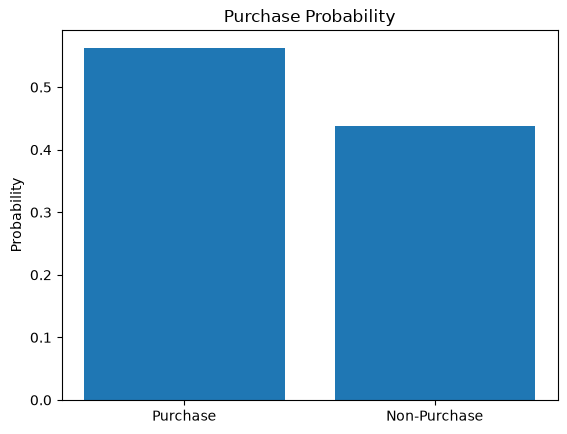

In [3]:
# 문제 2 코드를 작성하세요.
total_customers = len(probability_df)
purchase_customers = (probability_df["PurchaseYN"] == 1).sum()

p = purchase_customers / total_customers
non_p = 1 - p

value = p
variance = p * (1 - p)

print("전체 고객 수:", total_customers)
print("구매 고객 수:", purchase_customers)
print("구매확률:", p)
print("비구매확률:", non_p)
print("기대값:", value)
print("분산:", variance)

plt.bar(["Purchase", "Non-Purchase"], [p, non_p])
plt.ylabel("Probability")
plt.title("Purchase Probability")
plt.show()

# 문제 3. 고객 10명의 구매 고객 수 이항분포 분석

## 업무 상황

마케팅팀은 동일한 구매확률을 가진 고객 10명에게
동일한 캠페인을 진행한다고 가정합니다.

분석팀은 10명 중 몇 명이 구매할 가능성이 높은지와
평균적으로 예상되는 구매 고객 수를 계산해야 합니다.

## 요구사항

1. 고객 수 `n`을 10으로 설정합니다.
2. 구매 고객 수 0명부터 10명까지의 확률을 계산합니다.
3. 계산 결과를 표로 정리합니다.
4. 구매 고객 수에 따른 확률을 막대그래프로 표시합니다.
5. 기대 구매 고객 수를 계산합니다.
6. 이항분포의 분산을 계산합니다.
7. 가장 발생 가능성이 높은 구매 고객 수를 확인합니다.
8. 기대 구매 고객 수와 가장 가능성이 높은 구매 고객 수의 의미를 간단히 해석합니다.


,구매 고객 수,확률
0,0,0.000256
1,1,0.003295
2,2,0.019075
3,3,0.065434
4,4,0.147302
5,5,0.227385
6,6,0.243754
7,7,0.179178
8,8,0.086434
9,9,0.024708


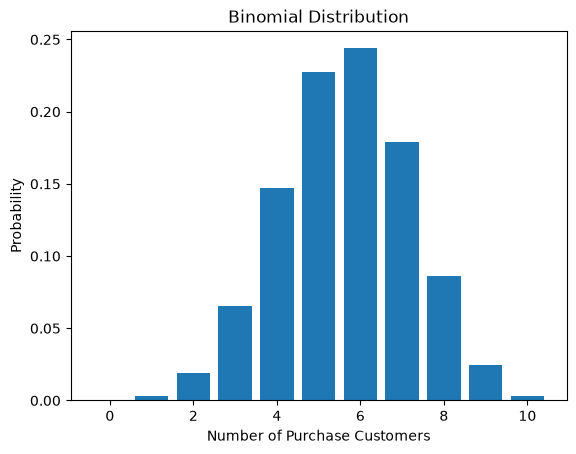

분산: 2.4607769143522127
기대 구매 고객 수: 5.626283367556468
가장 가능성이 높은 구매 고객 수: 6


In [4]:
# 문제 3 코드를 작성하세요.
n = 10

purchase_counts = []
probabilities = []

for k in range(n + 1):
    purchase_counts.append(k)
    probabilities.append(binom.pmf(k, n, p))

result = pd.DataFrame({
    "구매 고객 수": purchase_counts,
    "확률": probabilities
})

display(result)

plt.bar(purchase_counts, probabilities)
plt.xlabel("Number of Purchase Customers")
plt.ylabel("Probability")
plt.title("Binomial Distribution")
plt.show()

value = n * p
variance = n * p * (1 - p)

most_likely_count = 0
highest_probability = probabilities[0]

for i in range(len(probabilities)):
    if probabilities[i] > highest_probability:
        highest_probability = probabilities[i]
        most_likely_count = purchase_counts[i]

print("분산:", variance)
print("기대 구매 고객 수:", value)
print("가장 가능성이 높은 구매 고객 수:", most_likely_count)

>8번: 기대 구매 고객 수는 평균적으로 예상되는 구매 고객의 수이고 가장 가능성이 높은 구매 고객 수는 실제로 나올 가능성이 가장 높은 구매 고객 수이다.

# 문제 4. 확률분포 결과의 심화 해석

## 업무 상황

마케팅팀은 계산 결과를 실제 캠페인에 적용하기 전에,
구매금액 분포의 형태와 이항분포가 사용하는 가정의 한계를 추가로 확인하려고 합니다.

## 요구사항

### 4-1. 구매금액 분포 확인

1. `PurchaseAmount`의 히스토그램을 작성합니다.
2. 정규분포가 일반적으로 평균을 중심으로 좌우가 대칭적인 종 모양을 가진다는 점과 비교합니다.
3. 실제 히스토그램이 대칭적인지, 한쪽으로 치우쳐 있는지 등을 간단히 작성합니다.

> 정규성 검정, 왜도, 첨도는 계산하지 않습니다. 히스토그램의 전체적인 형태만 관찰합니다.

### 4-2. 동일한 구매확률 가정의 한계

다음 내용을 포함하여 작성합니다.

1. 이항분포 계산에서는 고객 10명이 모두 같은 구매확률 `p`를 가진다고 가정했다는 점
2. 실제 고객의 구매확률이 서로 다를 수 있는 이유
3. 실제 캠페인 적용 전에 추가로 구분하거나 확인할 고객 특성 2개 이상

예시 고객 특성: 방문횟수, 고객등급, 쿠폰 사용 여부, 최근 구매일, 연령, 지역


In [ ]:
# 심화 문제 4-1 코드를 작성하세요.


## 심화 문제 4-2 해석 작성

동일한 구매확률을 가정한 이항분포의 한계와 실제 적용 전 확인할 변수를 작성하세요.

> 여기에 심화 해석을 작성하세요.

# 제출 결과물

## 필수 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 데이터 유형표 | 연속형·이산형·이진형 변수 구분 및 구분 이유 |
| 이진형 값 확인 | `CouponUsed`, `PurchaseYN`의 고유값 확인 |
| 구매확률 분석 | 구매 고객 수, 구매확률, 비구매확률 |
| 베르누이분포 | 기대값과 분산 |
| 이항분포 | 고객 0~10명의 구매확률표와 그래프 |
| 예상 구매 고객 수 | 기대값, 분산, 가장 가능성이 높은 구매 고객 수 |
| 필수 해석 | 기대 구매 고객 수와 최빈 구매 고객 수의 기본 의미 |

## 심화 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 구매금액 히스토그램 | `PurchaseAmount` 분포 시각화 |
| 정규분포 비교 해석 | 대칭적 종 모양과 비교한 2문장 이상의 해석 |
| 이항분포 한계 해석 | 동일 구매확률 가정의 한계 및 추가 확인 변수 2개 이상 |

# 제출 전 체크리스트

## 필수 체크리스트

- [ ] 변수 유형을 올바르게 구분했습니다.
- [ ] 이진형 변수에 0과 1만 있는지 확인했습니다.
- [ ] 구매확률과 비구매확률을 계산했습니다.
- [ ] 베르누이 기대값과 분산을 계산했습니다.
- [ ] 고객 10명의 이항분포를 계산했습니다.
- [ ] 이항분포를 막대그래프로 표시했습니다.
- [ ] 기대 구매 고객 수와 분산을 계산했습니다.
- [ ] 가장 가능성이 높은 구매 고객 수를 확인했습니다.
- [ ] 필수 결과의 기본 의미를 해석했습니다.

## 심화 체크리스트

- [ ] `PurchaseAmount` 히스토그램을 작성했습니다.
- [ ] 정규분포의 대칭적 특성과 비교하여 분포를 해석했습니다.
- [ ] 정규성 검정, 왜도, 첨도 등 범위를 벗어난 분석을 추가하지 않았습니다.
- [ ] 동일한 구매확률 가정의 한계를 설명했습니다.
- [ ] 실제 적용 전 확인할 고객 특성을 2개 이상 제안했습니다.
